# Create Dataset Chapter 8 Workshop 13

In [ ]:
"""
Convert image to feature by following the steps:
1. Load the image.
2. Convert the image to grayscale.
3. Invert the grayscale image. [Black becomes white and vice versa]
4. Resize the image to a fixed size (e.g., 128x128, 28x28).
"""


from PIL import Image, ImageOps

# Defome the image file payh
imgfile = "D:\Project\Learning\TensorFlow_Files\image\digit\digit1.png"  # Replace with your image path
# Load the image
img = Image.open(imgfile)
# Convert the image to grayscale
img = img.convert("L")
# Invert the grayscale image
img = ImageOps.invert(img)
# Resize the image to a fixed size
img = img.resize((28, 28), Image.Resampling.LANCZOS)  # Change size as needed


## Visualization

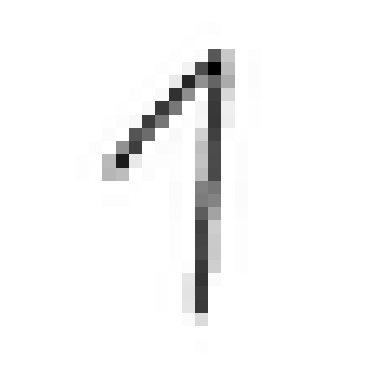

In [9]:
import matplotlib.pyplot as plt
# Display the image
plt.imshow(img, cmap=plt.cm.gray_r)
plt.axis("off")
plt.show()

## Scaler

In [16]:
import numpy as np

scale = 255.0
max_value = 255.0 # np.max(img)

pixel = np.array(img)
pixel = pixel / max_value * scale

pixel = pixel.astype('int')

## Reshape

In [22]:
digit_1 = pixel.flatten()
# digit_2 = pixel.reshape(1, -1)[0]

# element_check = digit_1 == digit_2 
# check = all(element_check)
# print(digit_1)
# print(digit_2)
# print(check)

## Define dataframe and append numpy array to it

In [34]:
import pandas as pd

df = pd.DataFrame([digit_1])
# Add data to the DataFrame
df = pd.concat([df, pd.DataFrame([digit_1])], ignore_index=True)

df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Deploy model on Web Chapter 8 Workshop 14

## Server

In [ ]:
import numpy as np
import json
from flask import Flask, request
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps

model_path = "D:\Project\Learning\TensorFlow_Files\model\handwrite_number_model.h5"
model = load_model(model_path)

# Show input shape
print('model:', model.get_config()['layers'][0]['config']['batch_shape'])

app = Flask(__name__)
@app.route('/predict', methods=['POST'])
def run_model():
    # Get request data
    req_data = request.get_json(force=True)
    
    print('req_data type :', type(req_data))

    if isinstance(req_data, str):
        req_data = json.loads(req_data)

    try:
        img_data = req_data['img']
    except Exception as e:
        print('Error:', e)
        return str(1)

    # print('img_data:', img_data)
    
    # Reshape the image data
    img_data = np.array(img_data).reshape(28, 28, 1)
    img_data = np.expand_dims(img_data, axis=0)

    # Predict the digit
    pred = model.predict(img_data)

    digit = np.argmax(pred, axis=1)[0]

    return str(digit)

if __name__ == "__main__":
    app.run()



model: (None, 28, 28, 1)


## Client

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.image import rgb_to_grayscale
from PIL import Image, ImageOps
import requests

# Defome the image file payh
imgfile = "D:\Project\Learning\TensorFlow_Files\image\digit\digit9.png"  # Replace with your image path
# Load the image
img = load_img(imgfile, target_size=(28, 28))
# Invert the image colors
img = ImageOps.invert(img)
# Transform to numpy array
img_arr = img_to_array(img)
# Convert to grayscale
img_arr = rgb_to_grayscale(img_arr)
# Normalize the image
img_arr = img_arr / 255.0

# Convert to list
img_lst = np.squeeze(img_arr).tolist()

# Convert to JSON
data = json.dumps({"img": img_lst})
# Define the URL of the server
url = 'http://127.0.0.1:5000/predict'

# Send the request to the server
res = requests.post(url, json=data)
# Print the response
print('Predict: ',res.text)


# Convert .h5 to TensorFlow Lite (TFlite) Chapter 8 Workshop 15

## Normal

In [40]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Load the model
model_path = "D:\Project\Learning\TensorFlow_Files\model\handwrite_number_model.h5"
model = load_model(model_path)
# Convert model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float_model = converter.convert()

f = open("./model/handwrite_number_model.tflite", "wb")
f.write(tflite_float_model)
f.close()

float_model_size = len(tflite_float_model)/1024
print('Model size:', float_model_size, 'KB')

INFO:tensorflow:Assets written to: C:\Users\autoy\AppData\Local\Temp\tmp1slb4sw_\assets


INFO:tensorflow:Assets written to: C:\Users\autoy\AppData\Local\Temp\tmp1slb4sw_\assets


Saved artifact at 'C:\Users\autoy\AppData\Local\Temp\tmp1slb4sw_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1794819853008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819860112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819859920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819860880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819859728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819862224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819861840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819863568: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model size: 882.35546875 KB


## Optimization

In [41]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

f = open("./model/handwrite_number_model_quant.tflite", "wb")
f.write(tflite_quantized_model)
f.close()

quant_model_size = len(tflite_quantized_model)/1024
print('Model size:', quant_model_size, 'KB')

INFO:tensorflow:Assets written to: C:\Users\autoy\AppData\Local\Temp\tmpuz7g5s7y\assets


INFO:tensorflow:Assets written to: C:\Users\autoy\AppData\Local\Temp\tmpuz7g5s7y\assets


Saved artifact at 'C:\Users\autoy\AppData\Local\Temp\tmpuz7g5s7y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1794819853008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819860112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819859920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819860880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819859728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819862224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819861840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1794819863568: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model size: 226.9921875 KB


## Use TFlite model files

In [50]:
import tensorflow as tf
from time import time
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.image import rgb_to_grayscale



imgfile = "D:\Project\Learning\TensorFlow_Files\image\digit\digit4.png"  # Replace with your image path
tflite_path = "./model/handwrite_number_model.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
input_tensor_index = input_details[0]['index']
output_details = interpreter.tensor(interpreter.get_output_details()[0]['index'])

# test_image
test_img = load_img(imgfile, target_size=(28, 28))
# Invert the image colors
test_img = ImageOps.invert(test_img)
# Transform to numpy array
test_img_arr = img_to_array(test_img)
# Convert to grayscale
test_img_arr = rgb_to_grayscale(test_img_arr)
# Normalize the image
test_img_arr = test_img_arr / 255.0

test_img_arr = np.expand_dims(test_img_arr, axis=0)

print('Input shape:', test_img_arr.shape)
print('Min:', np.min(test_img_arr))
print('Max:', np.max(test_img_arr))

start = time()

interpreter.set_tensor(input_tensor_index, test_img_arr)
# Predict the digit
interpreter.invoke()

end = time()
print('Time:', end - start)

print('Output:', output_details())
digit = np.argmax(output_details(), axis=1)
print('Digit:', digit[0])


Input shape: (1, 28, 28, 1)
Min: 0.0
Max: 0.99990004
Time: 0.0
Output: [[7.1155657e-05 1.3382923e-04 2.9346508e-03 5.1755334e-05 9.9379599e-01
  1.5979532e-04 2.3649775e-03 2.5484833e-04 3.0107487e-05 2.0283373e-04]]
Digit: 4
